<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/SFDS/dragon_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Royal Draconic Conservatory - Regression**

# **Importing Libraries**

In [6]:
!pip -q install plotly scikit-learn tabulate pandas

In [7]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px
from scipy.stats import kurtosis


#Feature engineering, selection and Model training
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error


#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate
from IPython.display import display


# **Data acquisition**

In [8]:
# Loading Data
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/SFDS/dragon_data.csv"
df = pd.read_csv(url)
df.head()

,SPC,AGE,MASS,WSP,HID,SPD,FHO
0,Wyvern,16,1304,4.0,4.83,4800,611
1,Dragon,2726,3693174,52.0,4.82,114400,1960
2,Dragon,377,154201,19.4,4.61,42680,1123
3,Hydra,169,40146,13.0,2.65,7800,706
4,Dragon,1571,1549315,39.6,1.49,87120,1441


In [9]:
# Create the data as a list of dictionaries
variables = [

    {"variable": "FHO", "description": "The target variable — Flame Heat Output (in degrees Celsius)."},
    {"variable": "WSP", "description": "Wingspan (in meters)."},
    {"variable": "MASS", "description": "Mass (in metric tons)."},
    {"variable": "AGE", "description": "Age (in years)."},
    {"variable": "SPD", "description": "Sustained flight speed (in km/h)."},
    {"variable": "HID", "description": "Hide thickness (in cm)."},
    {"variable": "SPC", "description": "Species (e.g. Dragon, Wyvern or Hyrdra)."},

]

# Display the DataFrame
var_desc = pd.DataFrame(variables)
var_desc_final = var_desc.reset_index(drop = True)

# Display the DataFrame
print(tabulate(var_desc_final, headers = 'keys', tablefmt = 'grid'))

+----+------------+---------------------------------------------------------------+
|    | variable   | description                                                   |
+====+============+===============================================================+
|  0 | FHO        | The target variable — Flame Heat Output (in degrees Celsius). |
+----+------------+---------------------------------------------------------------+
|  1 | WSP        | Wingspan (in meters).                                         |
+----+------------+---------------------------------------------------------------+
|  2 | MASS       | Mass (in metric tons).                                        |
+----+------------+---------------------------------------------------------------+
|  3 | AGE        | Age (in years).                                               |
+----+------------+---------------------------------------------------------------+
|  4 | SPD        | Sustained flight speed (in km/h).                       

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AGE,500.0,461.4740,643.250280,-481.00,105.5000,240.00,585.00,5407.0
MASS,500.0,309248.6900,751723.845284,17.00,19392.2500,79675.00,282531.50,9729833.0
WSP,500.0,18.1994,11.503709,1.00,10.4000,15.60,24.20,73.6
HID,500.0,2.9993,1.167213,1.01,1.9175,2.94,4.04,5.0
SPD,500.0,24157.1200,26568.849928,600.00,7665.0000,13890.00,29550.00,161920.0
FHO,500.0,894.2440,350.478483,100.00,664.0000,871.50,1109.50,2358.0


# **Data Transformation**

In [13]:
df_semi = df.copy()
# initialise encoder
le = LabelEncoder()

# Encoding Species  variable
df_semi['SPC_encoded'] = le.fit_transform(df['SPC'])

- LabelEncoder() provides a simple, consistent, and lossless way to convert variables to numeric because most machine learning algorithms can only work with numbers, not text or categories.

In [14]:
df_semi.head()

,SPC,AGE,MASS,WSP,HID,SPD,FHO,SPC_encoded
0,Wyvern,16,1304,4.0,4.83,4800,611,2
1,Dragon,2726,3693174,52.0,4.82,114400,1960,0
2,Dragon,377,154201,19.4,4.61,42680,1123,0
3,Hydra,169,40146,13.0,2.65,7800,706,1
4,Dragon,1571,1549315,39.6,1.49,87120,1441,0


In [15]:
df_semi.columns

Index(['SPC', 'AGE', 'MASS', 'WSP', 'HID', 'SPD', 'FHO', 'SPC_encoded'], dtype='object')

In [18]:
#  final dataframe
df_final = df_semi[['AGE', 'MASS', 'WSP', 'HID', 'SPD', 'SPC_encoded', 'FHO']]

# Rename specific columns
df_final = df_final.rename(columns={
    'SPC_encoded': 'SPC'
})

In [19]:
df_final.head()

,AGE,MASS,WSP,HID,SPD,SPC,FHO
0,16,1304,4.0,4.83,4800,2,611
1,2726,3693174,52.0,4.82,114400,0,1960
2,377,154201,19.4,4.61,42680,0,1123
3,169,40146,13.0,2.65,7800,1,706
4,1571,1549315,39.6,1.49,87120,0,1441


#### Data Split
Splitting data into training and testing sets is essential to evaluate a model's performance on new, unseen data and prevent overfitting. The training set teaches the model patterns, while the untouched test set provides an unbiased assessment of its generalisation ability, ensuring the model performs accurately in real-world scenarios rather than just on the data it learned from.


In [23]:
# features and target variable
#X = df_final.drop(['FHO'], axis = 1)
#y = df_final['FHO']

In [22]:
# Split into train and test (70/30)
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size = 0.3, random_state = 42
#)

# **Single Variable Regression**



from WSP


=== Regression using WSP ===
Training R²: 0.495
Test R²: 0.542


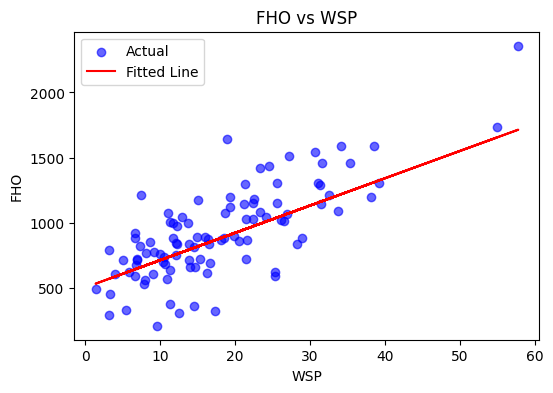


=== Regression using MASS ===
Training R²: 0.332
Test R²: 0.360


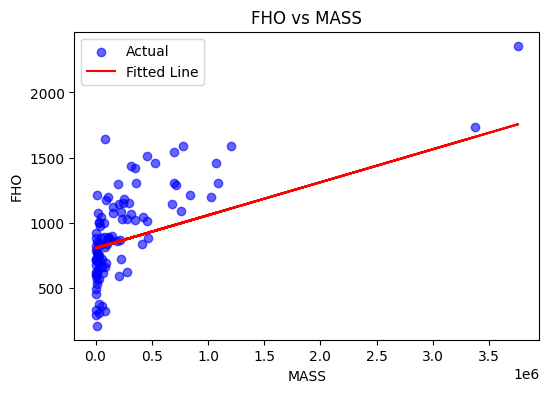


=== Regression using AGE ===
Training R²: 0.434
Test R²: 0.479


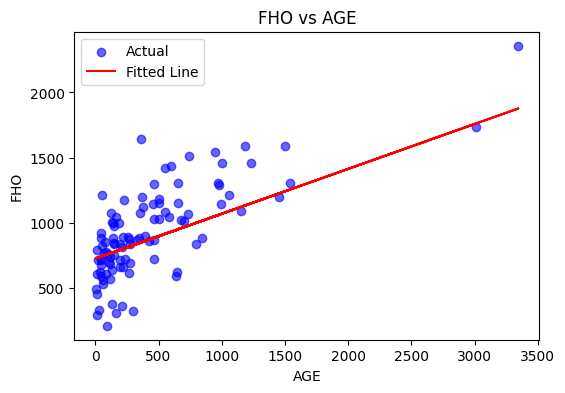


=== Regression using SPC ===
Training R²: 0.021
Test R²: 0.038


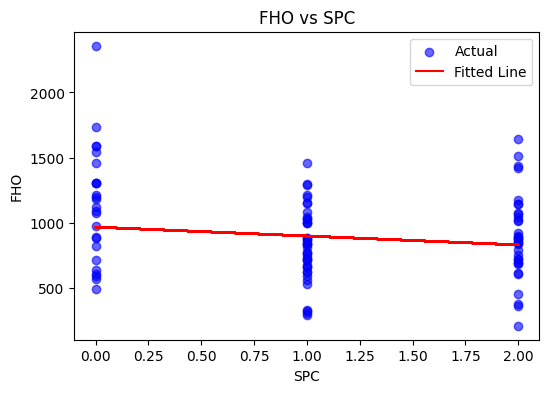


Summary of R² values:
  Variable  Train_R2   Test_R2
0      WSP  0.494672  0.541654
1     MASS  0.331680  0.360062
2      AGE  0.433590  0.478681
3      SPC  0.020791  0.037955


In [24]:
results = []

# Define target
y = df_final['FHO']

# Variables for single-variable regression
variables = ['WSP', 'MASS', 'AGE', 'SPC']

for var in variables:
    print(f"\n=== Regression using {var} ===")

    X = df_final[[var]]  # Keep as DataFrame for sklearn

    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Initialize and train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    print(f"Training R²: {r2_train:.3f}")
    print(f"Test R²: {r2_test:.3f}")

    # Save results
    results.append({
        'Variable': var,
        'Train_R2': r2_train,
        'Test_R2': r2_test
    })

    # Plot
    plt.figure(figsize=(6,4))
    plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='Actual')
    plt.plot(X_test, y_test_pred, color='red', label='Fitted Line')
    plt.xlabel(var)
    plt.ylabel('FHO')
    plt.title(f'FHO vs {var}')
    plt.legend()
    plt.show()

# Convert results to DataFrame for easy comparison
results_df = pd.DataFrame(results)
print("\nSummary of R² values:")
print(results_df)

# **Multiple Variable Regression**



In [ ]:
# Evaluation Results
#print(tabulate(results_df, headers='keys', tablefmt='grid'))